#### XCOM NIST Database
#### Pb

$\mu[Pb(1 keV)]     = 5209 cm^2/g       $
$\mu[Pb(10 keV)]    = 130.6 cm^2/g     $
$\mu[Pb(100 keV)]   = 5.549 cm^2/g    $
$\mu[Pb(1 MeV)]     = 0.1146 cm^2/g     $
$\mu[Pb(10 MeV)]    = 0.1190 cm^2/g    $  
$\mu[Pb(100 MeV)]   = 0.1197 cm^2/g   $
$\mu[Pb(1 GeV)]     = 0.1146 cm^2/g     $
$\mu[Pb(10 GeV)]    = 0.1190 cm^2/g    $
$\mu[Pb(100 GeV)]   = 0.1197 cm^2/g   $

#### W

$\mu[W(1 keV)]      = 3683 cm^2/g        $
$\mu[W(10 keV)]     = 96.9 cm^2/g       $
$\mu[W(100 keV)]    = 4.437 cm^2/g     $
$\mu[W(1 MeV)]      = 0.06618 cm^2/g     $
$\mu[W(10 MeV)]     = 0.04747 cm^2/g    $
$\mu[W(100 MeV)]    = 0.08796cm^2/g    $
$\mu[W(1 GeV)]      = 0.1082 cm^2/g      $
$\mu[W(10 GeV)]     = 0.1124 cm^2/g     $
$\mu[W(100 GeV)]    = 0.1131 cm^2/g    $

#### O

$\mu[O(1 keV)]      = 4590 cm^2/g        $
$\mu[O(10 keV)]     = 5.953 cm^2/g      $
$\mu[O(100 keV)]    = 0.1551 cm^2/g    $    
$\mu[O(1 MeV)]      = 0.06372  cm^2/g    $
$\mu[O(10 MeV)]     = 0.02089 cm^2/g    $
$\mu[O(100 MeV)]    = 0.01794 cm^2/g   $
$\mu[O(1 GeV)]      = 0.02128 cm^2/g     $
$\mu[O(10 GeV)]     = 0.02223 cm^2/g    $
$\mu[O(100 GeV)]    = 0.02240 cm^2/g   $

#### Attenuation coefficient $I(x)=I_0\,e^{-\mu\cdot x}$

mu =  0.7294347191208791  cm^-1
lambda =  1.3709245992639458  cm


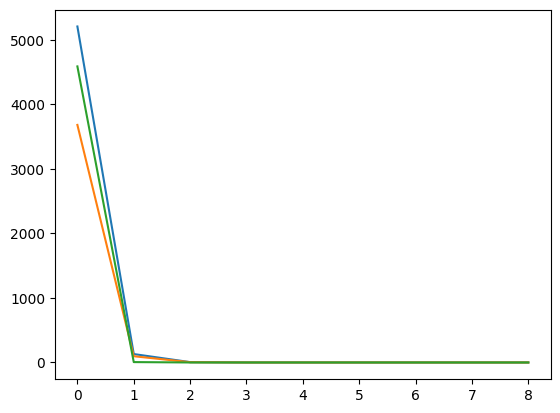

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

density = 8.3 # g/cm^3
atomic_mass_Pb = 207.2 # g/mol
atomic_mass_W = 183.8 # g/mol
atomic_mass_O = 16.0 # g/mol
atomic_mass_PbWO4 = atomic_mass_Pb + atomic_mass_W + 4 * atomic_mass_O

"""CHANGE HERE THE VALUES LOOKING AT THE NIST XCOM DATABASE"""
# Values set for 10 MeV
mu_mass_Pb = 0.1190 # cm^2/g
mu_mass_W = 0.04747 # cm^2/g
mu_mass_O = 0.02089 # cm^2/g

                          # 1 KeV, 10 KeV, 100 KeV, 1 MeV, 10 MeV, 100 MeV, 1 GeV, 10 GeV, 100 GeV
mu_mass_Pb_list = np.array([5209, 130.6, 5.549, 0.1146, 0.1190, 0.1197, 0.1146, 0.1190, 0.1197])
mu_mass_W_list = np.array([3683, 96.9, 4.437, 0.06618, 0.04747, 0.08796, 0.1082, 0.1124, 0.1131])
mu_mass_O_list = np.array([4590, 5.953, 0.1551, 0.06372, 0.02089, 0.01794, 0.02128, 0.02223, 0.02240])

energy_map = ["1 KeV", "10 KeV", "100 KeV", "1 MeV", "10 MeV", "100 MeV", "1 GeV", "10 GeV", "100 GeV"]

# mu_mass = mu_mass_Pb * (atomic_mass_Pb/atomic_mass_PbWO4) + mu_mass_W * (atomic_mass_W/atomic_mass_PbWO4) + mu_mass_O * (4*atomic_mass_O/atomic_mass_PbWO4)
pos = input(int("Select energy value considering the following matches:\n1 KeV - 0\n10 KeV - 1\n100 KeV - 2\n1 MeV - 3\n10 MeV - 4\n100 MeV - 5\n1 GeV - 6\n10 GeV - 7\n100 GeV - 8"))
mu_mass = mu_mass_Pb_list[pos] * (atomic_mass_Pb/atomic_mass_PbWO4) + mu_mass_W_list[pos] * (atomic_mass_W/atomic_mass_PbWO4) + mu_mass_O_list[pos] * (4*atomic_mass_O/atomic_mass_PbWO4)

mu_mass_global_list = []
for i in range(pos):
    mu_mass_global_list = mu_mass_Pb_list[i] * (atomic_mass_Pb/atomic_mass_PbWO4) + mu_mass_W_list[i] * (atomic_mass_W/atomic_mass_PbWO4) + mu_mass_O_list[i] * (4*atomic_mass_O/atomic_mass_PbWO4)

mu = mu_mass * density # cm^-1
lambda_ass = 1/mu # cm

#print(atomic_mass_W/atomic_mass_PbWO4)
print(f"mu = ", mu, " cm^-1")
print(f"lambda = ", lambda_ass, " cm")

plt.plot(mu_mass_Pb_list)
plt.plot(mu_mass_W_list)
plt.plot(mu_mass_O_list)
#plt.plot(mu_mass_global_list)


#### Interaction length

$\lambda_{\text{int}} = \frac{1}{n \sigma_{\text{nucl}}} = \frac{A}{N_A \rho} \cdot \frac{1}{\pi R_0^2 A^{2/3}} \approx 34 \, g \, cm^{-2} \times \frac{A^{1/3}}{\rho}$


In [3]:
import numpy as np

pi                  = np.pi
mass_number         = 474 # PbWO4
molecular_weight    = 455 # g/mol, or molar_mass
avogadro            = 6.02214076e23
density             = 8.3 # g/cm^3
nuclear_radius      = 5.1e-13 # cm --> average molecular radius

std_int_length = 0.92
exp_int_length = ( mass_number / (avogadro*density) ) * ( 1 / ( np.pi * (nuclear_radius**2) * (mass_number**(2/3) ) ) )
approx_int_length = 34*(mass_number**(1/3)/density)
print(exp_int_length)
print(approx_int_length)

1.9090042455133416
31.939413616530487


In [4]:
z_length = 120 # cm
5.92*std_int_length

5.446400000000001

#### Energy consumption

In [5]:
gpt3_energy_consumption = 190_000 # kWh
ita_house_year_consumption = 2_700 # kWh
ita_houses = gpt3_energy_consumption / ita_house_year_consumption
print(f"Italian houses yearly powered: ",ita_houses)

electric_car_consumption = (12+25)/2 # kWh/100km
total_distance = gpt3_energy_consumption / electric_car_consumption *100 # km
print(f"Total electric car distance traveled: ",total_distance)

Italian houses yearly powered:  70.37037037037037
Total electric car distance traveled:  1027027.027027027


#### $1/e$ fraction loss in radiation $\chi_0$ /interaction $\lambda_{int}$ length definitions

In [6]:
import numpy as np
f = 1/np.e
print(f"f={f}\n1-f={1-f}")

f=0.36787944117144233
1-f=0.6321205588285577


#### Compilation time of `genPhotons.cpp`

In [7]:
compilation_time_ROOTfile = 6510/60
print(f"Compilation time for ROOT file: {compilation_time_ROOTfile:.2f} minutes")

Compilation time for ROOT file: 108.50 minutes


#### Spike Rasterplot

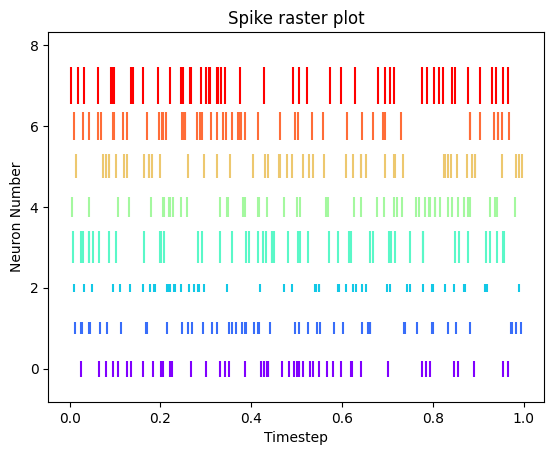

In [8]:
import matplotlib.pyplot as plot
import numpy as np
import matplotlib.cm as cm

# Set the random seed for data generation
np.random.seed(2)

# Create rows of random data with 50 data points simulating rows of spike trains
neuralData = np.random.random([8, 50])

# Set different colors for each neuron
colorCodes1 = np.array([[0, 0, 0], [1, 0, 0], [0, 1, 0], [0, 0, 1],
                       [1, 1, 0], [1, 0, 1], [0, 1, 1], [1, 0, 1]])
colorCodes2 = np.array([
    [0.5, 0.5, 0.5],  # Grigio
    [1, 0.5, 0],      # Arancione
    [0, 0.5, 0.5],    # Verde acqua
    [0.5, 0, 0.5],    # Viola
    [0.5, 0.5, 0],    # Giallo scuro
    [0, 0.5, 1],      # Azzurro
    [0.5, 0, 0],      # Marrone
    [0, 0, 0.5]       # Blu scuro
])

colorCodes3 = cm.rainbow(np.linspace(0, 1, 8))

# Set spike colors for each neuron
lineSize = [0.4, 0.3, 0.2, 0.8, 0.5, 0.6, 0.7, 0.9]                                  

# Draw a spike raster plot
plot.eventplot(neuralData, color=colorCodes3, linelengths = lineSize)     
plot.title('Spike raster plot')
plot.xlabel('Timestep')
plot.ylabel('Neuron Number')
plot.show()

### Spike vs SurrogateGradient plots

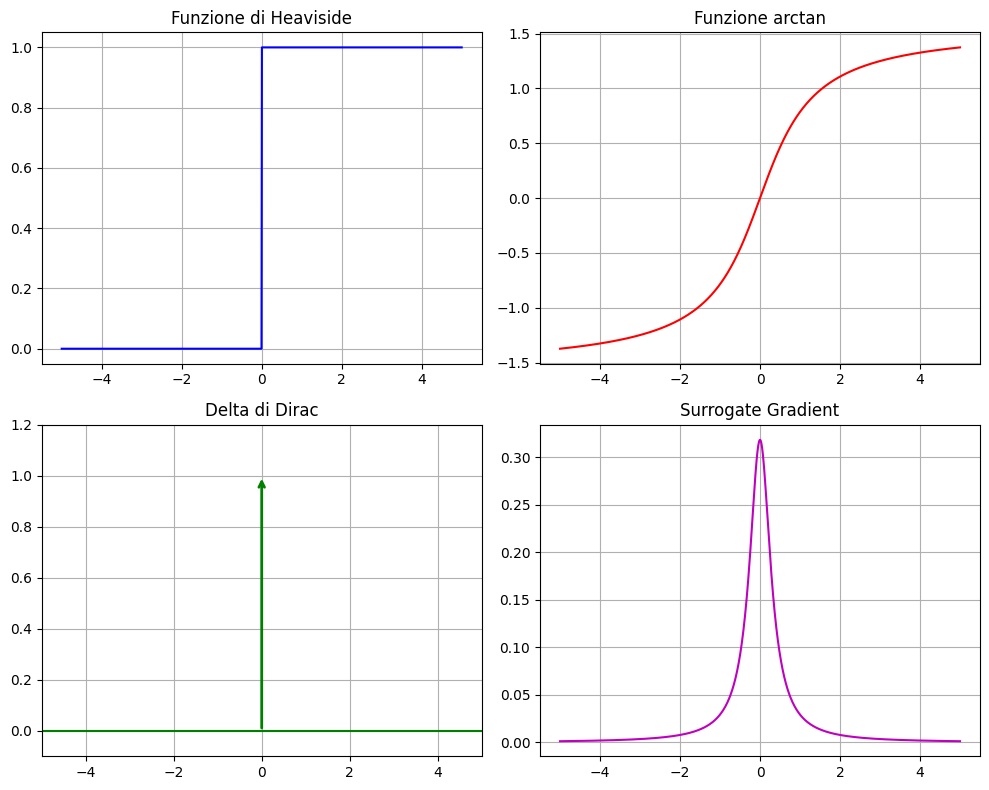

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Definizione dell'intervallo di x
x = np.linspace(-5, 5, 1000)

heaviside = np.heaviside(x, 1)
arctan = np.arctan(x)
surrogate_gradient = ( 1/np.pi )* ( 1 / (1 + (x*np.pi)**2) )

# Creazione della figura con una matrice 2x2 di subplot
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Traccia i grafici nei rispettivi subplot
axes[0, 0].plot(x, heaviside, label=r'$\Theta(x)$', color='b')
axes[0, 0].set_title("Funzione di Heaviside")
axes[0, 0].grid()

axes[0, 1].plot(x, arctan, label=r'$\arctan(x)$', color='r')
axes[0, 1].set_title("Funzione arctan")
axes[0, 1].grid()

# Grafico della Delta di Dirac con una freccia
axes[1, 0].axhline(0, color='g')  # Linea zero
axes[1, 0].annotate("", xy=(0, 1), xytext=(0, 0),
                     arrowprops=dict(facecolor='g', edgecolor='g', arrowstyle='->', linewidth=2))
axes[1, 0].set_xlim([-5, 5])
axes[1, 0].set_ylim([-0.1, 1.2])
axes[1, 0].set_title("Delta di Dirac")
axes[1, 0].grid()

axes[1, 1].plot(x, surrogate_gradient, label=r'$1/(1+x^2)$', color='m')
axes[1, 1].set_title("Surrogate Gradient")
axes[1, 1].grid()

# Layout e visualizzazione
plt.tight_layout()
plt.show()


/tmp/ipykernel_124355/3557161019.py:20: UserWarning: Legend does not support handles for Annotation instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()


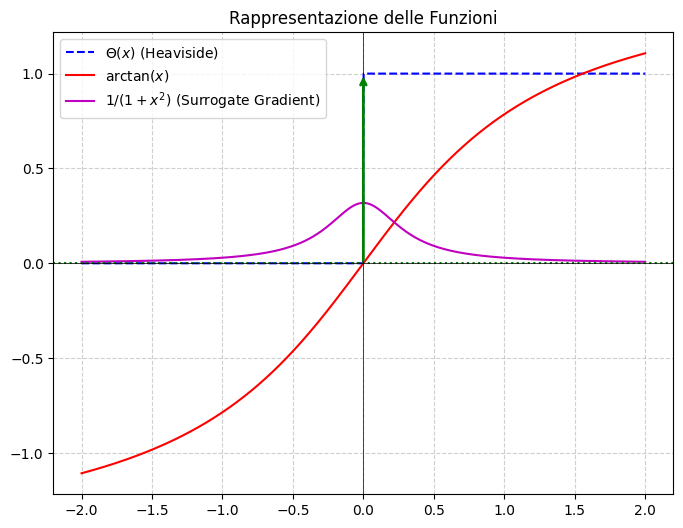

In [13]:
# Creazione della figura
plt.figure(figsize=(8, 6))

# Plottiamo le funzioni
plt.plot(x, heaviside, label=r'$\Theta(x)$ (Heaviside)', color='b', linestyle='--')
plt.plot(x, arctan, label=r'$\arctan(x)$', color='r')
plt.plot(x, surrogate_gradient, label=r'$1/(1+x^2)$ (Surrogate Gradient)', color='m')

# Aggiungiamo la Delta di Dirac con una freccia
plt.axhline(0, color='g', linestyle=':')
plt.annotate("", xy=(0, 1), xytext=(0, 0),
             arrowprops=dict(facecolor='g', edgecolor='g', arrowstyle='->', linewidth=2),
             label=r'$\delta(x)$ (Delta di Dirac)')

# Aggiungiamo titolo e griglia
plt.title("Rappresentazione delle Funzioni")
plt.axhline(0, color='black', linewidth=0.5)  # Asse x
plt.axvline(0, color='black', linewidth=0.5)  # Asse y
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Mostriamo il grafico

plt.show()